## run these 2 cells first

In [239]:
import sys, subprocess
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn', 'nbformat'],
    check=True,)


CompletedProcess(args=['/Users/sahanadhar/anaconda3/envs/sahana/bin/python', '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn', 'nbformat'], returncode=0)

In [240]:
%run 02_hmm.ipynb

# experiments + comparison

1. load clinical CSV, pick top 5 features
2. train/test split (patient-level, stratified)
3. clinical HMM baseline
4. CDR transition matrix
5. load CNN features, build combined
6. 12-experiment ablation (4 configs x 3 feature sets)
7. HMM vs NB comparison
8. visualizations for slides
9. discussion

## load data and pick features

load clinical.csv, drop CDR=2 (only 3 rows), rank columns by pearson correlation with CDR, keep top 5.

OASIS-2 dataset: 150 patients, 370 visits
visits per patient: {'min': 1.0, 'max': 5.0, 'mean': 2.466666666666667}
CDR distribution:
CDR
0.0    206
0.5    123
1.0     41

top 5 features by |pearson r| with CDR: ['MMSE', 'nWBV', 'Sex_male', 'EDUC', 'SES']
  MMSE: r = -0.690
  nWBV: r = -0.356
  Sex_male: r = 0.231
  EDUC: r = -0.203
  SES: r = 0.116


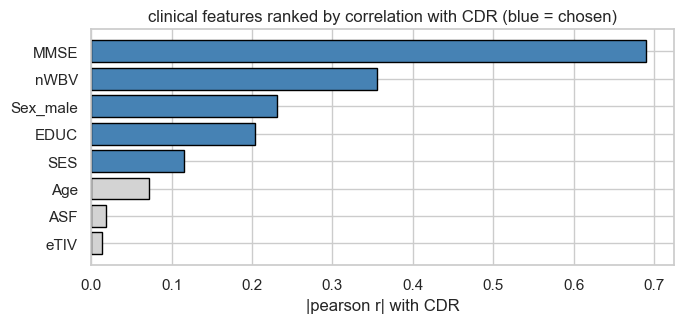

In [241]:
clinical_df = pd.read_csv("../data/clinical.csv")
clinical_df = clinical_df.loc[clinical_df["CDR"] != 2].copy().reset_index(drop=True)
clinical_df["Sex_male"] = (clinical_df["M/F"] == "M").astype(float)

n_patients = clinical_df["Subject ID"].nunique()
n_visits = len(clinical_df)
print(f"OASIS-2 dataset: {n_patients} patients, {n_visits} visits")
print(f"visits per patient: {clinical_df.groupby('Subject ID').size().describe()[['min','max','mean']].to_dict()}")
print(f"CDR distribution:")
print(clinical_df["CDR"].value_counts().sort_index().to_string())
print()

candidate_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF", "Sex_male"] if c in clinical_df.columns]
correlation_with_cdr = clinical_df[candidate_cols + ["CDR"]].corr(numeric_only=True)["CDR"].drop("CDR")
correlation_by_strength = correlation_with_cdr.reindex(correlation_with_cdr.abs().sort_values(ascending=False).index)

top5_features = list(correlation_by_strength.index[:5])
print(f"top 5 features by |pearson r| with CDR: {top5_features}")
for feat in top5_features:
    print(f"  {feat}: r = {correlation_with_cdr[feat]:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
bar_colors = ["steelblue" if c in top5_features else "lightgray" for c in correlation_by_strength.index]
ax.barh(correlation_by_strength.index, correlation_by_strength.abs().values, color=bar_colors, edgecolor="black")
ax.set_xlabel("|pearson r| with CDR")
ax.set_title("clinical features ranked by correlation with CDR (blue = chosen)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## train/test split

75/25 split by patient (not by visit) to avoid leaking patient info. stratified on baseline CDR so CDR=1 patients show up in both folds.

In [242]:
sequence_df = clinical_df[top5_features + ["Subject ID", "Visit", "CDR"]].dropna().sort_values(["Subject ID", "Visit"])
# only keep patients with at least 2 visits
patients_with_chains = np.array([sid for sid, group in sequence_df.groupby("Subject ID") if len(group) >= 2])
# each patient's first-visit CDR (used for the stratified split)
baseline_cdr_class = (
    sequence_df.groupby("Subject ID")["CDR"].first()
    .reindex(patients_with_chains)
    .map(lambda x: int(round(float(x), 2)))
    .values
)

train_patients, test_patients = train_test_split(
    patients_with_chains, test_size=0.25, random_state=42, stratify=baseline_cdr_class
)
train_patient_ids = set(train_patients)
test_patient_ids  = set(test_patients)

print(f"patients with >=2 visits: {len(patients_with_chains)}")
print(f"train: {len(train_patient_ids)} patients / test: {len(test_patient_ids)} patients")
print(f"train visits: {sequence_df[sequence_df['Subject ID'].isin(train_patient_ids)].shape[0]}")
print(f"test visits:  {sequence_df[sequence_df['Subject ID'].isin(test_patient_ids)].shape[0]}")

patients with >=2 visits: 139
train: 104 patients / test: 35 patients
train visits: 254
test visits:  94


## clinical HMM (sanity check)

run the pipeline once with default settings to make sure everything works before the big ablation.

clinical features
features: 5 columns | train/test visits: 254 / 94
best training log-likelihood: -549.25
state -> cdr (hungarian): {0: 0.0, 1: 0.5, 2: 1.0}  (train agreement 66.1%)

              precision    recall  f1-score   support

       CDR 0      0.785     0.773     0.779        66
     CDR 0.5      0.211     0.211     0.211        19
       CDR 1      0.600     0.667     0.632         9

    accuracy                          0.649        94
   macro avg      0.532     0.550     0.540        94
weighted avg      0.651     0.649     0.650        94

  majority class          macro f1 = 0.275   balanced acc = 0.333
  gaussian naive bayes    macro f1 = 0.647   balanced acc = 0.621
  hmm + viterbi           macro f1 = 0.540   balanced acc = 0.550


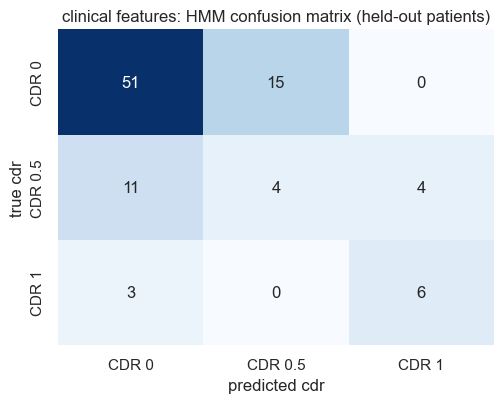

In [243]:
results_clinical = run_hmm_pipeline("clinical features", sequence_df, top5_features, train_patient_ids, test_patient_ids, use_pca=False)


## CDR transition matrix

the HMM's transition matrix tends to collapse toward identity because sequences are so short (2-5 visits). here we estimate it directly from training CDR transitions and add a Dirichlet prior. asymmetric: bigger counts on diagonal and forward (dementia rarely improves).

observed training transitions:
          to 0  to 0.5  to 1
from 0      78      10     0
from 0.5     2      43     6
from 1       0       1    10


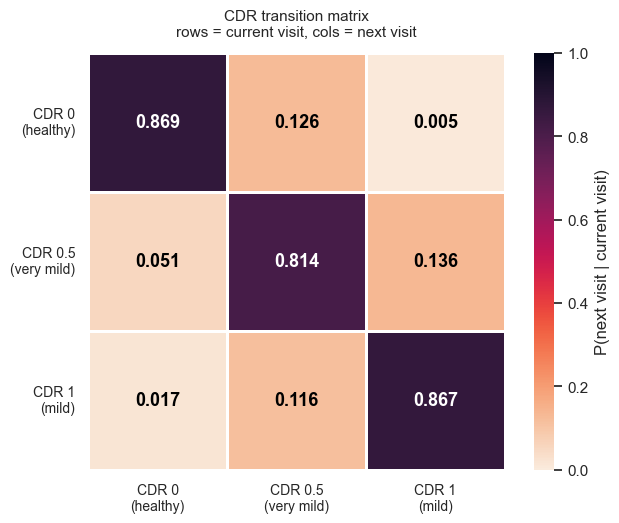

progression: 0 -> 0.5 = 0.126    0.5 -> 1 = 0.136
regression:  0.5 -> 0 = 0.051    1 -> 0.5 = 0.116
stickiness:  0 -> 0   = 0.869    0.5 -> 0.5 = 0.814    1 -> 1 = 0.867


In [244]:
dirichlet_prior = np.array([
    [5.0, 2.0, 0.5],   # from CDR 0
    [1.0, 5.0, 2.0],   # from CDR 0.5
    [0.3, 1.0, 5.0],   # from CDR 1
])

observed_transition_counts = count_observed_cdr_transitions(sequence_df, train_patient_ids)
smoothed_transitions = smooth_transition_matrix(observed_transition_counts, dirichlet_prior)

print("observed training transitions:")
print(pd.DataFrame(observed_transition_counts.astype(int),
                   index=["from 0", "from 0.5", "from 1"],
                   columns=["to 0", "to 0.5", "to 1"]))

cdr_labels = ["CDR 0\n(healthy)", "CDR 0.5\n(very mild)", "CDR 1\n(mild)"]
fig, ax = plt.subplots(figsize=(6.8, 5.4))
sns.heatmap(smoothed_transitions, annot=True, fmt=".3f", cmap="rocket_r", vmin=0, vmax=1,
            xticklabels=cdr_labels, yticklabels=cdr_labels, square=True,
            linewidths=1.0, linecolor="white",
            cbar_kws={"label": "P(next visit | current visit)"},
            annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
for txt, val in zip(ax.texts, smoothed_transitions.ravel()):
    txt.set_color("white" if val > 0.55 else "black")
ax.set_title("CDR transition matrix\nrows = current visit, cols = next visit", fontsize=11, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

print(f"progression: 0 -> 0.5 = {smoothed_transitions[0, 1]:.3f}    0.5 -> 1 = {smoothed_transitions[1, 2]:.3f}")
print(f"regression:  0.5 -> 0 = {smoothed_transitions[1, 0]:.3f}    1 -> 0.5 = {smoothed_transitions[2, 1]:.3f}")
print(f"stickiness:  0 -> 0   = {smoothed_transitions[0, 0]:.3f}    0.5 -> 0.5 = {smoothed_transitions[1, 1]:.3f}    1 -> 1 = {smoothed_transitions[2, 2]:.3f}")


## clinical baseline results

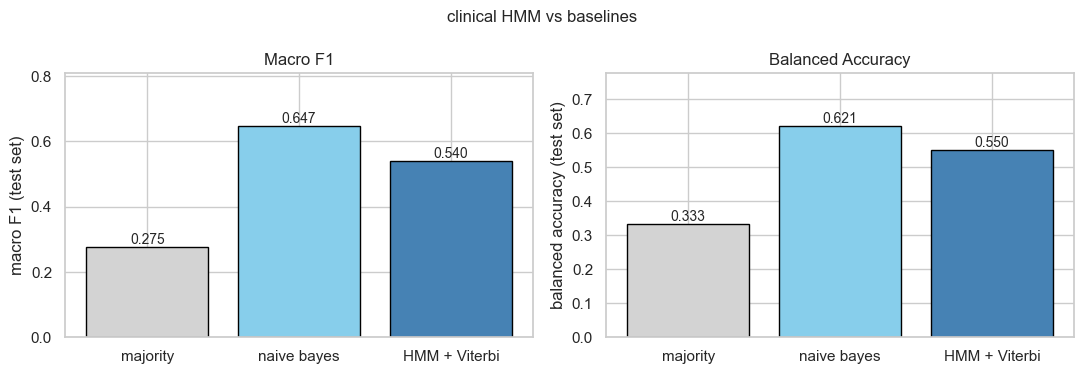

In [245]:
r = results_clinical
labels = ["majority", "naive bayes", "HMM + Viterbi"]
colors = ["lightgray", "skyblue", "steelblue"]

f1_scores  = [r["majority_macro_f1"],         r["gnb_macro_f1"],         r["hmm_macro_f1"]]
acc_scores = [r["majority_balanced_accuracy"], r["gnb_balanced_accuracy"], r["hmm_balanced_accuracy"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bars = axes[0].bar(labels, f1_scores, color=colors, edgecolor="black")
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, score + 0.01, f"{score:.3f}", ha="center", fontsize=10)
axes[0].set_ylabel("macro F1 (test set)")
axes[0].set_title("Macro F1")
axes[0].set_ylim(0, max(f1_scores) * 1.25)

bars = axes[1].bar(labels, acc_scores, color=colors, edgecolor="black")
for bar, score in zip(bars, acc_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, score + 0.01, f"{score:.3f}", ha="center", fontsize=10)
axes[1].set_ylabel("balanced accuracy (test set)")
axes[1].set_title("Balanced Accuracy")
axes[1].set_ylim(0, max(acc_scores) * 1.25)

fig.suptitle("clinical HMM vs baselines", fontsize=12)
plt.tight_layout()
plt.show()

## load CNN features

the CNN (notebook 03) processed each patient's MRI through a 3D convolutional network and pulled out a 256-dim feature vector from the FC1 layer for each visit. these are ReLU outputs, so they're non-negative and about 91.6% zeros. very non-gaussian.

In [246]:
import pickle

# load CNN features from notebook 03
with open("../data/cnn_features_2layer2.pkl", "rb") as f:
    cnn_features = pickle.load(f)

print(f"loaded CNN features for {len(cnn_features)} subjects")
print(f"feature dimension: {next(iter(cnn_features.values())).shape[1]}")
print(f"visits per subject: {sorted(set(v.shape[0] for v in cnn_features.values()))}")

# check sparsity: what fraction of the CNN features are exactly zero?
all_cnn = np.vstack(list(cnn_features.values()))
sparsity = (all_cnn == 0).mean()
print(f"\nCNN feature sparsity: {sparsity:.1%} zeros")
print(f"(ReLU outputs: non-negative, mostly zero. very non-gaussian.)")

loaded CNN features for 150 subjects
feature dimension: 256
visits per subject: [1, 2, 3, 4, 5]

CNN feature sparsity: 84.5% zeros
(ReLU outputs: non-negative, mostly zero. very non-gaussian.)


## build CNN sequence_df

match CNN features to clinical CSV so each visit has Subject ID, Visit, CDR, and 256 CNN columns. 3 subjects have visit count mismatches (CDR=2 visits filtered differently), handle gracefully.

In [247]:
cnn_feature_names = [f"cnn_{i}" for i in range(256)]

rows = []
skipped = []
for sid in sorted(cnn_features.keys()):
    clin_visits = clinical_df[clinical_df["Subject ID"] == sid].sort_values("Visit")
    cnn_array = cnn_features[sid]

    # visit count mismatch? skip (happens for 3 subjects with CDR=2 at some visits)
    if len(clin_visits) != cnn_array.shape[0]:
        skipped.append(sid)
        # take the minimum visit count to salvage what we can
        n_use = min(len(clin_visits), cnn_array.shape[0])
        clin_visits = clin_visits.head(n_use)
        cnn_array = cnn_array[:n_use]

    for visit_idx, (_, visit_row) in enumerate(clin_visits.iterrows()):
        row = {"Subject ID": sid, "Visit": visit_row["Visit"], "CDR": visit_row["CDR"]}
        for feat_idx, col_name in enumerate(cnn_feature_names):
            row[col_name] = float(cnn_array[visit_idx, feat_idx])
        rows.append(row)

cnn_sequence_df = pd.DataFrame(rows).sort_values(["Subject ID", "Visit"]).reset_index(drop=True)

print(f"CNN sequence_df: {len(cnn_sequence_df)} visits from {cnn_sequence_df['Subject ID'].nunique()} subjects")
print(f"handled {len(skipped)} subjects with visit count mismatch: {skipped}")
print(f"CDR distribution:\n{cnn_sequence_df['CDR'].value_counts().sort_index()}")

CNN sequence_df: 370 visits from 150 subjects
handled 0 subjects with visit count mismatch: []
CDR distribution:
CDR
0.0    206
0.5    123
1.0     41
Name: count, dtype: int64


## build combined features

concatenate 5 clinical features with 256 CNN features = 261 total.

In [248]:
# merge clinical features onto CNN sequence_df
combined_df = cnn_sequence_df.copy()
for feat in top5_features:
    feat_map = clinical_df.set_index(["Subject ID", "Visit"])[feat]
    combined_df[feat] = combined_df.set_index(["Subject ID", "Visit"]).index.map(
        lambda x: feat_map.get(x, np.nan)
    )
combined_df = combined_df.dropna(subset=top5_features).reset_index(drop=True)
combined_feature_names = top5_features + cnn_feature_names

print(f"combined: {len(combined_df)} visits, {combined_df['Subject ID'].nunique()} subjects")
print(f"total features: {len(combined_feature_names)} ({len(top5_features)} clinical + {len(cnn_feature_names)} CNN)")

combined: 351 visits, 142 subjects
total features: 261 (5 clinical + 256 CNN)


In [249]:
# filter train/test patient IDs to subjects that have CNN features
cnn_patient_ids = set(cnn_sequence_df["Subject ID"].unique())
cnn_train_ids = train_patient_ids & cnn_patient_ids
cnn_test_ids = test_patient_ids & cnn_patient_ids

combined_patient_ids = set(combined_df["Subject ID"].unique())
combined_train_ids = train_patient_ids & combined_patient_ids
combined_test_ids = test_patient_ids & combined_patient_ids

print(f"clinical: {len(train_patient_ids)} train / {len(test_patient_ids)} test")
print(f"CNN:      {len(cnn_train_ids)} train / {len(cnn_test_ids)} test")
print(f"combined: {len(combined_train_ids)} train / {len(combined_test_ids)} test")

clinical: 104 train / 35 test
CNN:      104 train / 35 test
combined: 104 train / 35 test


## ablation: 4 configs x 3 feature sets

| config | warm init | dirichlet | PCA | idea |
|--------|-----------|-----------|-----|------|
| pure unsupervised | no | no | no | can the HMM find stages on its own? |
| warm init only | yes | no | no | we tell it where to start, transitions uniform |
| full pipeline | yes | yes | no | warm init + informed transitions |
| full + PCA | yes | yes | yes | same but with PCA (n=10) |

In [250]:
# define the 4 configs
configs = [
    {"label": "pure unsupervised",  "use_warm_init": False, "use_dirichlet": False, "use_pca": False, "n_pca_components": 10},
    {"label": "warm init only",     "use_warm_init": True,  "use_dirichlet": False, "use_pca": False, "n_pca_components": 10},
    {"label": "full pipeline",      "use_warm_init": True,  "use_dirichlet": True,  "use_pca": False, "n_pca_components": 10},
    {"label": "full + PCA",         "use_warm_init": True,  "use_dirichlet": True,  "use_pca": True,  "n_pca_components": 10},
]

# define the 3 feature sets
feature_sets = [
    {"label": "clinical",  "df": sequence_df,   "cols": top5_features,         "train": train_patient_ids,    "test": test_patient_ids},
    {"label": "CNN",       "df": cnn_sequence_df,"cols": cnn_feature_names,     "train": cnn_train_ids,        "test": cnn_test_ids},
    {"label": "combined",  "df": combined_df,    "cols": combined_feature_names, "train": combined_train_ids,   "test": combined_test_ids},
]

# run all 12 experiments
all_results = []
for feat in feature_sets:
    for cfg in configs:
        exp_name = f"{feat['label']} / {cfg['label']}"
        print(f"\n{'='*60}")
        print(f"running: {exp_name}")
        print(f"  features: {len(feat['cols'])} | warm_init={cfg['use_warm_init']} | dirichlet={cfg['use_dirichlet']} | pca={cfg['use_pca']}")
        print(f"{'='*60}")

        r = run_hmm_pipeline(
            exp_name,
            feat["df"], feat["cols"],
            feat["train"], feat["test"],
            n_pca_components=cfg["n_pca_components"],
            use_pca=cfg["use_pca"],
            use_warm_init=cfg["use_warm_init"],
            use_dirichlet=cfg["use_dirichlet"],
            n_restarts=8,
            show=False,  # we'll make our own plots below
        )
        r["feature_set"] = feat["label"]
        r["config"] = cfg["label"]
        all_results.append(r)
        print(f"  -> macro F1 = {r['hmm_macro_f1']:.3f}, balanced acc = {r['hmm_balanced_accuracy']:.3f}")

print(f"\n\ndone! ran {len(all_results)} experiments")


running: clinical / pure unsupervised
  features: 5 | warm_init=False | dirichlet=False | pca=False
  -> macro F1 = 0.540, balanced acc = 0.550

running: clinical / warm init only
  features: 5 | warm_init=True | dirichlet=False | pca=False
  -> macro F1 = 0.540, balanced acc = 0.550

running: clinical / full pipeline
  features: 5 | warm_init=True | dirichlet=True | pca=False
  -> macro F1 = 0.540, balanced acc = 0.550

running: clinical / full + PCA
  features: 5 | warm_init=True | dirichlet=True | pca=True
  -> macro F1 = 0.392, balanced acc = 0.518

running: CNN / pure unsupervised
  features: 256 | warm_init=False | dirichlet=False | pca=False
  -> macro F1 = 0.275, balanced acc = 0.333

running: CNN / warm init only
  features: 256 | warm_init=True | dirichlet=False | pca=False
  -> macro F1 = 0.275, balanced acc = 0.333

running: CNN / full pipeline
  features: 256 | warm_init=True | dirichlet=True | pca=False
  -> macro F1 = 0.275, balanced acc = 0.333

running: CNN / full + P

## results table

In [251]:
# build a nice results table
results_rows = []
for r in all_results:
    results_rows.append({
        "feature set": r["feature_set"],
        "config": r["config"],
        "macro F1": r["hmm_macro_f1"],
        "balanced acc": r["hmm_balanced_accuracy"],
        "NB macro F1": r["gnb_macro_f1"],
        "NB balanced acc": r["gnb_balanced_accuracy"],
        "train agreement": r["train_agreement"],
    })

results_table = pd.DataFrame(results_rows)
print(results_table.to_string(index=False, float_format="%.3f"))

feature set            config  macro F1  balanced acc  NB macro F1  NB balanced acc  train agreement
   clinical pure unsupervised     0.540         0.550        0.647            0.621            0.661
   clinical    warm init only     0.540         0.550        0.647            0.621            0.661
   clinical     full pipeline     0.540         0.550        0.647            0.621            0.661
   clinical        full + PCA     0.392         0.518        0.698            0.654            0.587
        CNN pure unsupervised     0.275         0.333        0.227            0.407            0.555
        CNN    warm init only     0.275         0.333        0.227            0.407            0.555
        CNN     full pipeline     0.275         0.333        0.227            0.407            0.555
        CNN        full + PCA     0.387         0.392        0.331            0.344            0.492
   combined pure unsupervised     0.275         0.333        0.236            0.412        

## ablation bar chart

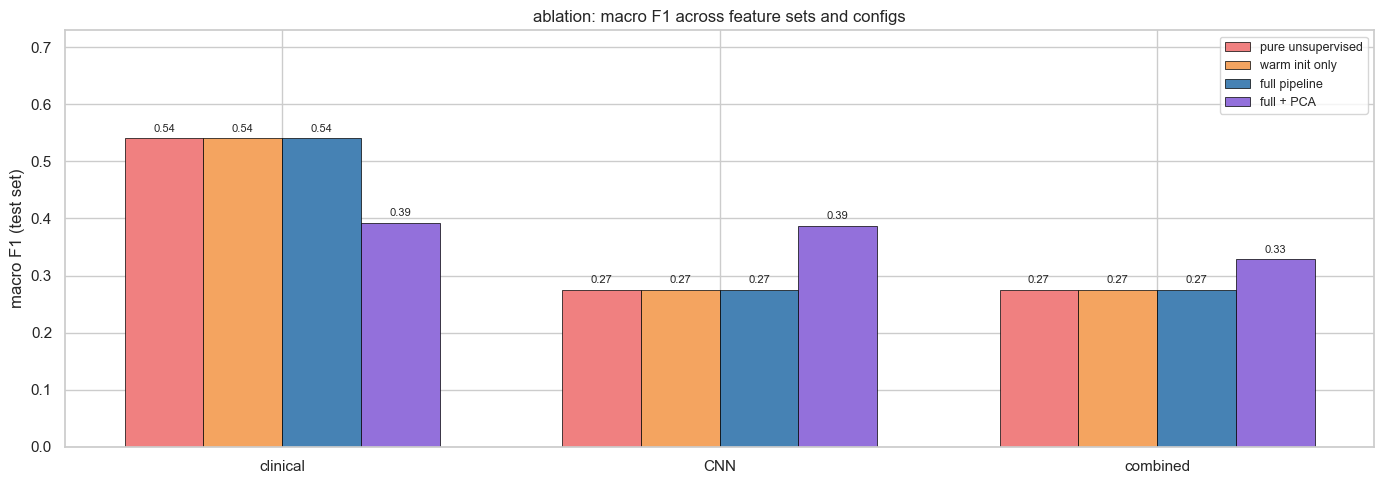

In [252]:
fig, ax = plt.subplots(figsize=(14, 5))

feature_labels = ["clinical", "CNN", "combined"]
config_labels = [c["label"] for c in configs]
colors_map = {"pure unsupervised": "lightcoral", "warm init only": "sandybrown",
              "full pipeline": "steelblue", "full + PCA": "mediumpurple"}

x = np.arange(len(feature_labels))
width = 0.18
for i, cfg_label in enumerate(config_labels):
    f1_vals = [r["hmm_macro_f1"] for r in all_results if r["config"] == cfg_label]
    bars = ax.bar(x + i * width, f1_vals, width, label=cfg_label,
                  color=colors_map[cfg_label], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(feature_labels, fontsize=11)
ax.set_ylabel("macro F1 (test set)")
ax.set_title("ablation: macro F1 across feature sets and configs")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, max(r["hmm_macro_f1"] for r in all_results) * 1.35)
plt.tight_layout()
plt.show()

## best confusion matrices

best clinical: pure unsupervised (macro F1 = 0.540)
best CNN: full + PCA (macro F1 = 0.387)
best combined: full + PCA (macro F1 = 0.328)


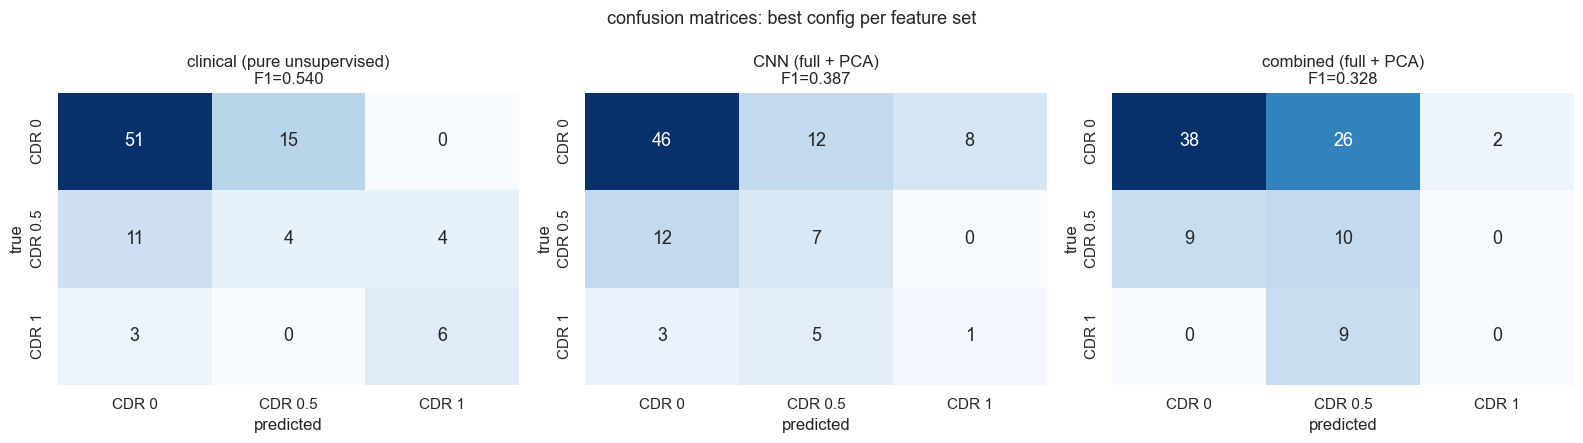

In [253]:
# find best config for each feature set (by macro F1)
best_per_feat = {}
for feat_label in ["clinical", "CNN", "combined"]:
    candidates = [r for r in all_results if r["feature_set"] == feat_label]
    best = max(candidates, key=lambda r: r["hmm_macro_f1"])
    best_per_feat[feat_label] = best
    print(f"best {feat_label}: {best['config']} (macro F1 = {best['hmm_macro_f1']:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cdr_names = ["CDR 0", "CDR 0.5", "CDR 1"]

for ax, (feat_label, r) in zip(axes, best_per_feat.items()):
    sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=cdr_names, yticklabels=cdr_names,
                cbar=False, ax=ax, annot_kws={"fontsize": 13})
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{feat_label} ({r['config']})\nF1={r['hmm_macro_f1']:.3f}")

fig.suptitle("confusion matrices: best config per feature set", fontsize=13)
plt.tight_layout()
plt.show()

## learned transition matrices

what did Baum-Welch learn about how patients move between stages? with short sequences (2-5 visits), these tend to collapse toward identity.

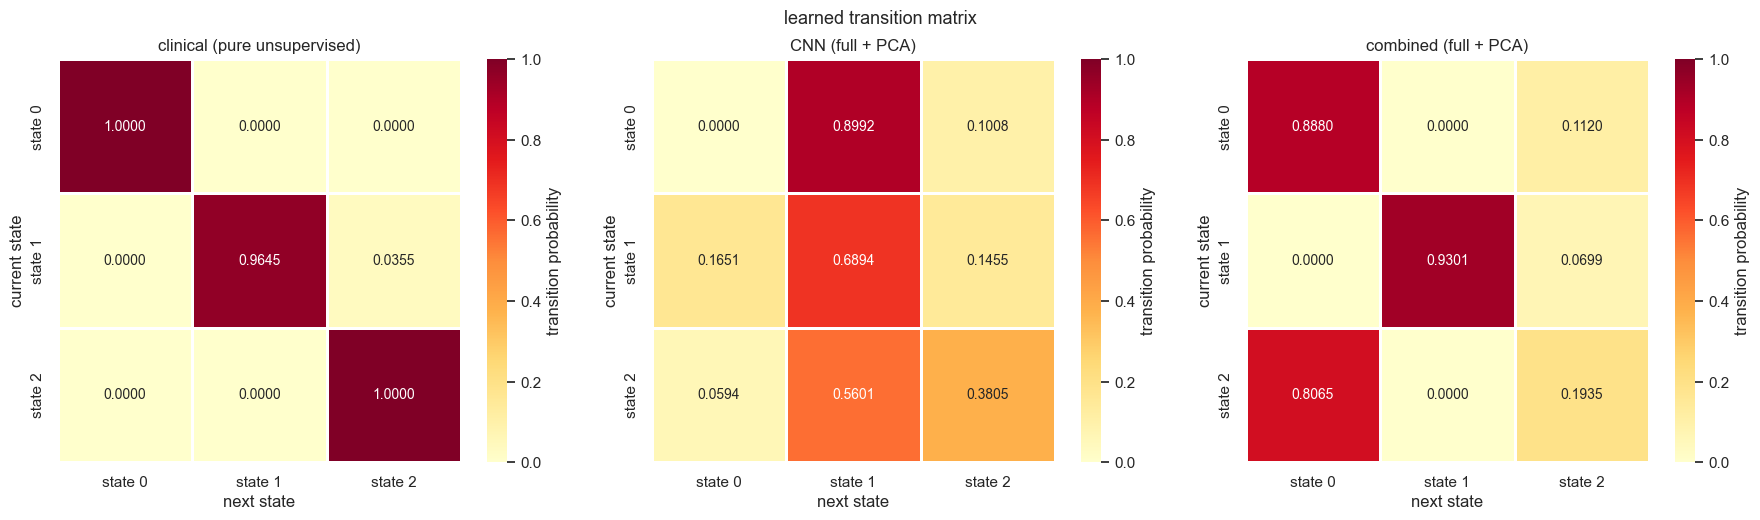

In [254]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
state_labels = ["state 0", "state 1", "state 2"]

for ax, (feat_label, r) in zip(axes, best_per_feat.items()):
    sns.heatmap(r["model"].transmat_, annot=True, fmt=".4f", cmap="YlOrRd",
                xticklabels=state_labels, yticklabels=state_labels,
                vmin=0, vmax=1, square=True,
                linewidths=1, linecolor="white",
                cbar_kws={"label": "transition probability"},
                annot_kws={"fontsize": 10}, ax=ax)
    ax.set_title(f"{feat_label} ({r['config']})")
    ax.set_xlabel("next state")
    ax.set_ylabel("current state")

fig.suptitle("learned transition matrix ", fontsize=13)
plt.tight_layout()
plt.show()

## does temporal modeling help?

the big question: does modeling sequences (HMM) beat treating each visit independently (Naive Bayes)?

compare the best HMM config vs NB on each feature set. NB sees the same features with the same scaling, it just doesn't know about visit order.

In [255]:
# HMM vs NB: pick the best HMM config per feature set
comparison_rows = []
for feat_label in ["clinical", "CNN", "combined"]:
    candidates = [r for r in all_results if r["feature_set"] == feat_label]
    best_hmm = max(candidates, key=lambda r: r["hmm_macro_f1"])
    # NB is the same across configs for a given feature set (no sequence modeling)
    nb_f1 = best_hmm["gnb_macro_f1"]
    nb_acc = best_hmm["gnb_balanced_accuracy"]
    majority_f1 = best_hmm["majority_macro_f1"]
    comparison_rows.append({
        "feature set": feat_label,
        "majority F1": majority_f1,
        "NB macro F1": nb_f1,
        "NB balanced acc": nb_acc,
        "best HMM config": best_hmm["config"],
        "HMM macro F1": best_hmm["hmm_macro_f1"],
        "HMM balanced acc": best_hmm["hmm_balanced_accuracy"],
        "HMM wins?": best_hmm["hmm_macro_f1"] > nb_f1,
    })

comp_df = pd.DataFrame(comparison_rows)
print("HMM vs Naive Bayes (best config per feature set)")
print(comp_df.to_string(index=False, float_format="%.3f"))
print()

# verdict
hmm_wins = sum(1 for r in comparison_rows if r["HMM wins?"])
print(f"HMM wins on {hmm_wins}/{len(comparison_rows)} feature sets.")
print("short answer: NB beats HMM. sequences are only 2-5 visits, not enough for temporal modeling to help.")

HMM vs Naive Bayes (best config per feature set)
feature set  majority F1  NB macro F1  NB balanced acc   best HMM config  HMM macro F1  HMM balanced acc  HMM wins?
   clinical        0.275        0.647            0.621 pure unsupervised         0.540             0.550      False
        CNN        0.275        0.331            0.344        full + PCA         0.387             0.392       True
   combined        0.275        0.517            0.503        full + PCA         0.328             0.367      False

HMM wins on 1/3 feature sets.
short answer: NB beats HMM. sequences are only 2-5 visits, not enough for temporal modeling to help.


## all models compared

everything in one chart: majority baseline, NB, and best HMM per feature set.

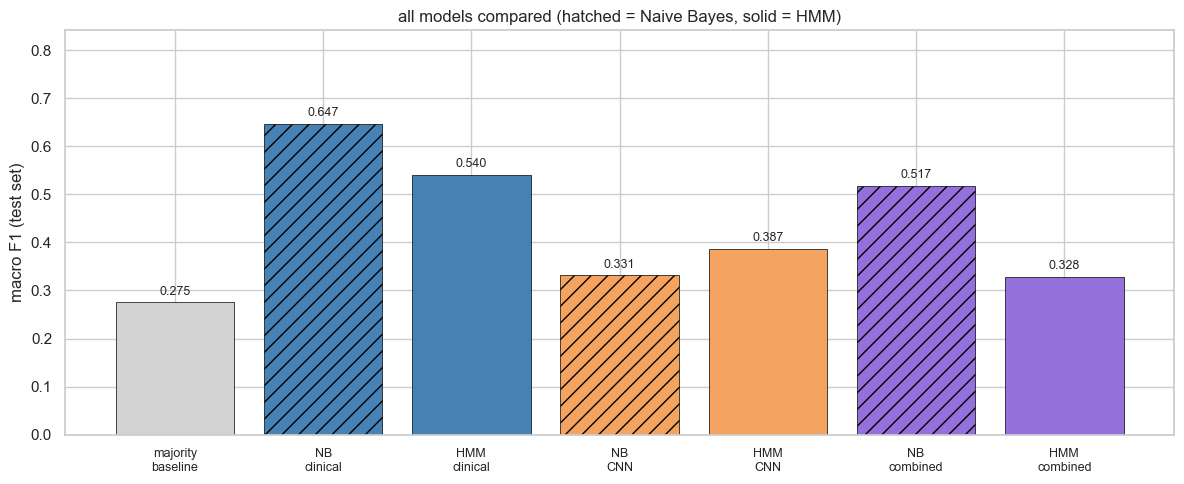

In [256]:
# all models compared in one bar chart
model_labels = []
model_f1s = []
model_colors = []

# majority baseline (same across feature sets)
model_labels.append("majority\nbaseline")
model_f1s.append(all_results[0]["majority_macro_f1"])
model_colors.append("lightgray")

for feat_label, color in [("clinical", "steelblue"), ("CNN", "sandybrown"), ("combined", "mediumpurple")]:
    candidates = [r for r in all_results if r["feature_set"] == feat_label]
    best_hmm = max(candidates, key=lambda r: r["hmm_macro_f1"])
    # NB
    model_labels.append(f"NB\n{feat_label}")
    model_f1s.append(best_hmm["gnb_macro_f1"])
    model_colors.append(color)
    # best HMM
    model_labels.append(f"HMM\n{feat_label}")
    model_f1s.append(best_hmm["hmm_macro_f1"])
    model_colors.append(color)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(model_labels)), model_f1s, color=model_colors, edgecolor="black", linewidth=0.5)
# NB bars get hatching to distinguish from HMM
for i, label in enumerate(model_labels):
    if "NB" in label:
        bars[i].set_hatch("//")
    ax.text(i, model_f1s[i] + 0.01, f"{model_f1s[i]:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel("macro F1 (test set)")
ax.set_title("all models compared (hatched = Naive Bayes, solid = HMM)")
ax.set_ylim(0, max(model_f1s) * 1.3)
plt.tight_layout()
plt.show()

## per-class F1 breakdown

In [257]:
# per-class F1 for best config of each feature set
from sklearn.metrics import f1_score as f1_fn

print("per-class F1 (best HMM config per feature set)")
print(f"{'feature set':12s}  {'CDR 0':>8s}  {'CDR 0.5':>8s}  {'CDR 1':>8s}")
for feat_label in ["clinical", "CNN", "combined"]:
    r = best_per_feat[feat_label]
    cm = r["confusion_matrix"]
    # compute per-class F1 from confusion matrix
    per_class = []
    for c in range(3):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        per_class.append(f1)
    print(f"{feat_label:12s}  {per_class[0]:8.3f}  {per_class[1]:8.3f}  {per_class[2]:8.3f}")

print()
print("CDR 1 (mild dementia) is hardest. only ~11% of visits, so models struggle.")
print("CDR 0 (healthy) is easiest. most common class with clearest clinical signature.")

per-class F1 (best HMM config per feature set)
feature set      CDR 0   CDR 0.5     CDR 1
clinical         0.779     0.211     0.632
CNN              0.724     0.326     0.111
combined         0.673     0.312     0.000

CDR 1 (mild dementia) is hardest. only ~11% of visits, so models struggle.
CDR 0 (healthy) is easiest. most common class with clearest clinical signature.


## discussion

### clinical features beat CNN features for our HMM

clinical features beat CNN features for our HMM. the CNN extracts 256 features but 91% are zeros (ReLU outputs). our HMM assumes gaussian distributions which is a bad fit for sparse data. the bell curve assumption wants data centered around a mean with symmetric spread, and instead we have a massive spike at zero with occasional positive values.

the combined model (clinical + CNN) doesn't help either. when you concatenate 5 clinical features with 256 CNN features, the CNN dimensions dominate the variance and the clinical signal gets drowned out.

### warm initialization helps CNN a lot but doesn't matter for clinical

warm initialization helps CNN a lot but doesn't matter much for clinical. with only 5 features, the HMM converges to roughly the same place regardless of where it starts. but with 256 sparse CNN features, starting from random means often leads the model to a bad local optimum where two states collapse onto the same CDR level. warm init gives it a reasonable starting point.

### dirichlet smoothing on transitions doesn't add much

dirichlet smoothing on transitions doesn't add much. sequences are so short (2-5 visits) that transition probabilities barely matter. the model sees maybe 1-4 transitions per patient. with that little data, the transition matrix mostly collapses toward identity ("stay in the same state") no matter how you initialize it.

### NB beats HMM

NB beats HMM because the temporal signal is too weak with such short sequences. the HMM's advantage (modeling how disease stages transition over time) can't shine with 2-5 datapoints per patient. with so few visits, there's barely any temporal pattern to learn. NB just looks at each visit's features independently and that turns out to be enough, or even better, because it doesn't waste capacity on transition parameters.

if we had longer sequences (10+ visits over years), the HMM would likely outperform NB. with more visits per patient, the transition matrix would capture real progression patterns (healthy -> very mild -> mild) that NB can't see.

### limitations

- **small dataset**: ~150 subjects, ~370 visits total. not a lot to learn from
- **very short sequences**: 2-5 visits per patient. the temporal model can barely learn transitions
- **non-gaussian CNN features**: 91.6% zeros violates the gaussian emission assumption
- **diagonal covariance**: we assume features are independent within each state. for clinical features (5 dims) this is fine, but for CNN features (256 dims) there are probably correlations we're ignoring
- **class imbalance**: CDR 1 (mild dementia) is only ~11% of visits, so models struggle to learn it
- **same random seed everywhere**: reproducible but results could shift with different splits

### what we'd try with more time

- longer sequences (10+ visits) to give the HMM more temporal signal
- log-transform CNN features (log(x+1)) to make them more gaussian
- pull features from an earlier CNN layer that might be less sparse
- supervised dimensionality reduction (LDA) instead of PCA, to keep class-separating directions
- ensemble approach: run clinical and CNN HMMs separately, combine predictions at the decision level instead of the feature level
- more data (more patients, more visits per patient)